# Phase 3 -- Qubit and circuit-depth ablation (hybrid quantum CNN)

This notebook explores the two one-factor-at-a-time (OFAT) sweeps over the hybrid model's quantum layer, using the same subset split as every other phase (digits 0/1/2, 300 train / 100 test per class).

- **Sweep A (qubit count)**: `n_qubits` in {2, 4, 6, 8}, `n_qlayers` held at the Phase 1 baseline (2).
- **Sweep B (circuit depth)**: `n_qlayers` in {1, 2, 3, 4}, `n_qubits` held at the Phase 1 baseline (4).

The `n_qubits=4, n_qlayers=2` point is the existing Phase 1 `hybrid_subset` run and is reused (copied, not retrained) in both sweeps -- see `results/ablation/qubits_4/REUSED_FROM.txt` and `results/ablation/depth_2/REUSED_FROM.txt`.

It loads the saved configs and metrics for both sweeps, compares final numbers, plots accuracy/parameter-count vs qubit count and accuracy vs depth, and evaluates confusion matrices for every trained (or reused) run.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import yaml
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.data.dataset import get_dataloaders
from src.models.hybrid_cnn import HybridCNN
from src.training.engine import evaluate
from src.training.metrics import confusion_matrix_fig
from src.utils.plotting import plot_ablation_depth, plot_ablation_qubits

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## Configuration

Points to the four Sweep A configs/results (`configs/ablation/qubits_*.yaml`) and the four Sweep B configs/results (`configs/ablation/depth_*.yaml`), plus the combined `results/ablation/metrics_summary.csv` written by `run_ablation.py`.

In [2]:
def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    config['dataset']['data_root'] = str(project_root / 'data')
    return config

SWEEP_A_RUNS = [
    {
        'label': f'qubits_{n}',
        'reused': n == 4,
        'config': project_root / 'configs' / 'ablation' / f'qubits_{n}.yaml',
        'results_dir': project_root / 'results' / 'ablation' / f'qubits_{n}',
    }
    for n in [2, 4, 6, 8]
]

SWEEP_B_RUNS = [
    {
        'label': f'depth_{n}',
        'reused': n == 2,
        'config': project_root / 'configs' / 'ablation' / f'depth_{n}.yaml',
        'results_dir': project_root / 'results' / 'ablation' / f'depth_{n}',
    }
    for n in [1, 2, 3, 4]
]

SUMMARY_CSV = project_root / 'results' / 'ablation' / 'metrics_summary.csv'

for spec in SWEEP_A_RUNS + SWEEP_B_RUNS:
    tag = ' (reused from Phase 1 baseline)' if spec['reused'] else ''
    print(f"{spec['label']}: {spec['config']}{tag}")

qubits_2: D:\Dissertation\qcnn-dissertation\configs\ablation\qubits_2.yaml
qubits_4: D:\Dissertation\qcnn-dissertation\configs\ablation\qubits_4.yaml (reused from Phase 1 baseline)
qubits_6: D:\Dissertation\qcnn-dissertation\configs\ablation\qubits_6.yaml
qubits_8: D:\Dissertation\qcnn-dissertation\configs\ablation\qubits_8.yaml
depth_1: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_1.yaml
depth_2: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_2.yaml (reused from Phase 1 baseline)
depth_3: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_3.yaml
depth_4: D:\Dissertation\qcnn-dissertation\configs\ablation\depth_4.yaml


## 1. Ablation configuration summary

Confirms every ablation config shares the same subset `dataset` block as the base models, and shows the (n_qubits, n_qlayers) grid point each run covers.

In [3]:
rows = []
for spec in SWEEP_A_RUNS + SWEEP_B_RUNS:
    if not spec['config'].exists():
        continue
    cfg = load_config(spec['config'])
    rows.append({
        'run': spec['label'],
        'n_qubits': cfg['model'].get('n_qubits'),
        'n_qlayers': cfg['model'].get('n_qlayers'),
        'epochs': cfg['training'].get('epochs'),
        'data_seed': cfg.get('data_seed'),
        'training_seed': cfg.get('training_seed'),
        'reused': spec['reused'],
    })

config_summary_df = pd.DataFrame(rows)
display(config_summary_df)

,run,n_qubits,n_qlayers,epochs,data_seed,training_seed,reused
0,qubits_2,2,2,15,42,42,False
1,qubits_4,4,2,15,42,42,True
2,qubits_6,6,2,15,42,42,False
3,qubits_8,8,2,15,42,42,False
4,depth_1,4,1,15,42,42,False
5,depth_2,4,2,15,42,42,True
6,depth_3,4,3,15,42,42,False
7,depth_4,4,4,15,42,42,False


## 2. Sweep A -- qubit count

Loads the `qubits` rows of `results/ablation/metrics_summary.csv` (final-epoch metrics per `n_qubits`, with `n_qlayers` fixed at 2) and displays `figures/ablation_qubits.png` (accuracy and parameter count vs qubit count).

,sweep,n_qubits,n_qlayers,accuracy,f1_macro,precision_macro,recall_macro,parameter_count,epoch_time_sec,seed,output_dir
4,qubits,2,2,0.993333,0.993333,0.993366,0.993333,1775.0,0.603161,42.0,results/ablation/qubits_2
5,qubits,4,2,0.976667,0.976814,0.978193,0.976667,2299.0,0.715185,42.0,results/ablation/qubits_4
6,qubits,6,2,0.996667,0.996667,0.996700,0.996667,2823.0,1.202888,42.0,results/ablation/qubits_6
7,qubits,8,2,0.980000,0.979982,0.981132,0.980000,3347.0,1.434543,42.0,results/ablation/qubits_8


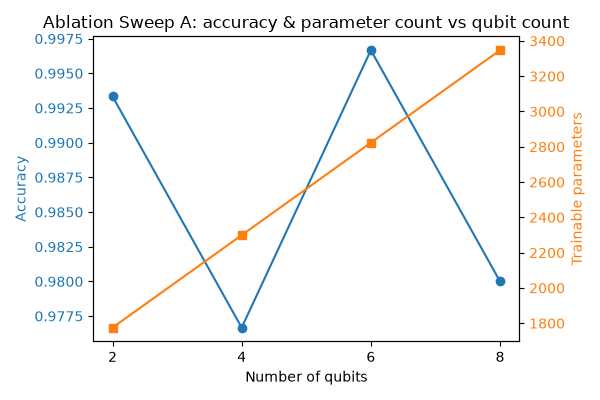

In [4]:
if SUMMARY_CSV.exists():
    summary_df = pd.read_csv(SUMMARY_CSV)
    sweep_a_df = summary_df[summary_df['sweep'] == 'qubits'].sort_values('n_qubits')
else:
    summary_df = None
    sweep_a_df = pd.DataFrame()

if not sweep_a_df.empty:
    display(sweep_a_df)
    fig_path = project_root / 'figures' / 'ablation_qubits.png'
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
else:
    print(
        f'No qubits-sweep rows found in {SUMMARY_CSV} -- run:\n'
        '  python -m src.experiments.run_ablation --sweep qubits'
    )

## 3. Sweep B -- circuit depth

Loads the `depth` rows of `results/ablation/metrics_summary.csv` (final-epoch metrics per `n_qlayers`, with `n_qubits` fixed at 4) and displays `figures/ablation_depth.png` (accuracy vs circuit depth).

,sweep,n_qubits,n_qlayers,accuracy,f1_macro,precision_macro,recall_macro,parameter_count,epoch_time_sec,seed,output_dir
0,depth,4,1,0.993333,0.993333,0.993333,0.993333,2295.0,0.601542,42.0,results/ablation/depth_1
1,depth,4,2,0.976667,0.976814,0.978193,0.976667,2299.0,0.715185,42.0,results/ablation/depth_2
2,depth,4,3,0.986667,0.986665,0.986890,0.986667,2303.0,0.802377,42.0,results/ablation/depth_3
3,depth,4,4,0.990000,0.990000,0.990097,0.990000,2307.0,0.856793,42.0,results/ablation/depth_4


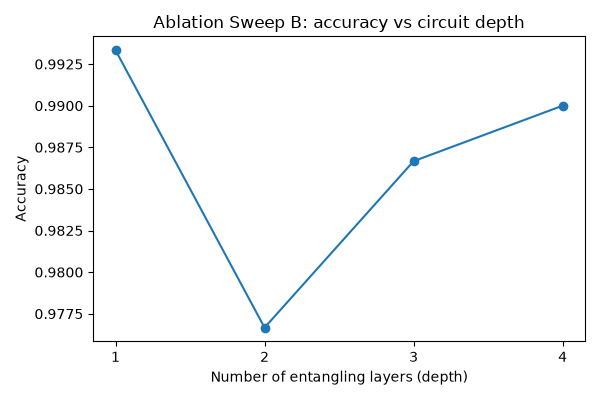

In [5]:
if SUMMARY_CSV.exists():
    summary_df = pd.read_csv(SUMMARY_CSV)
    sweep_b_df = summary_df[summary_df['sweep'] == 'depth'].sort_values('n_qlayers')
else:
    summary_df = None
    sweep_b_df = pd.DataFrame()

if not sweep_b_df.empty:
    display(sweep_b_df)
    fig_path = project_root / 'figures' / 'ablation_depth.png'
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
else:
    print(
        f'No depth-sweep rows found in {SUMMARY_CSV} yet -- run:\n'
        '  python -m src.experiments.run_ablation --sweep depth'
    )

## 4. Combined summary table

Every run from both sweeps, one row each -- the `n_qubits=4, n_qlayers=2` baseline point appears once per sweep since it is shared, not retrained twice.

In [6]:
if SUMMARY_CSV.exists():
    display(pd.read_csv(SUMMARY_CSV))
else:
    print(f'No summary file at {SUMMARY_CSV} yet.')

,sweep,n_qubits,n_qlayers,accuracy,f1_macro,precision_macro,recall_macro,parameter_count,epoch_time_sec,seed,output_dir
0,depth,4,1,0.993333,0.993333,0.993333,0.993333,2295.0,0.601542,42.0,results/ablation/depth_1
1,depth,4,2,0.976667,0.976814,0.978193,0.976667,2299.0,0.715185,42.0,results/ablation/depth_2
2,depth,4,3,0.986667,0.986665,0.986890,0.986667,2303.0,0.802377,42.0,results/ablation/depth_3
3,depth,4,4,0.990000,0.990000,0.990097,0.990000,2307.0,0.856793,42.0,results/ablation/depth_4
4,qubits,2,2,0.993333,0.993333,0.993366,0.993333,1775.0,0.603161,42.0,results/ablation/qubits_2
5,qubits,4,2,0.976667,0.976814,0.978193,0.976667,2299.0,0.715185,42.0,results/ablation/qubits_4
6,qubits,6,2,0.996667,0.996667,0.996700,0.996667,2823.0,1.202888,42.0,results/ablation/qubits_6
7,qubits,8,2,0.980000,0.979982,0.981132,0.980000,3347.0,1.434543,42.0,results/ablation/qubits_8


## 5. Confusion matrices

Evaluates every run with saved weights (trained or reused) on its own test split and saves/displays a confusion matrix per run.

Saved D:\Dissertation\qcnn-dissertation\results\ablation\qubits_2\confusion_matrix.png


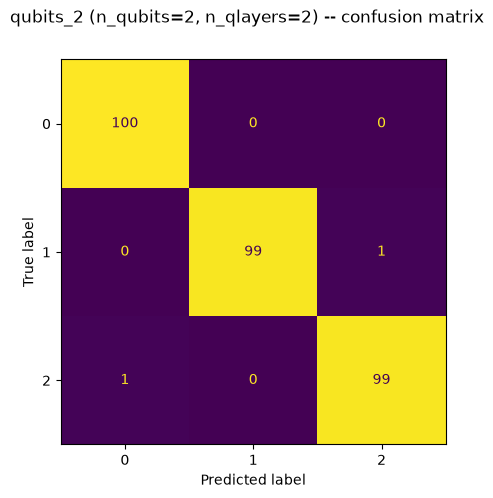

Saved D:\Dissertation\qcnn-dissertation\results\ablation\qubits_4\confusion_matrix.png


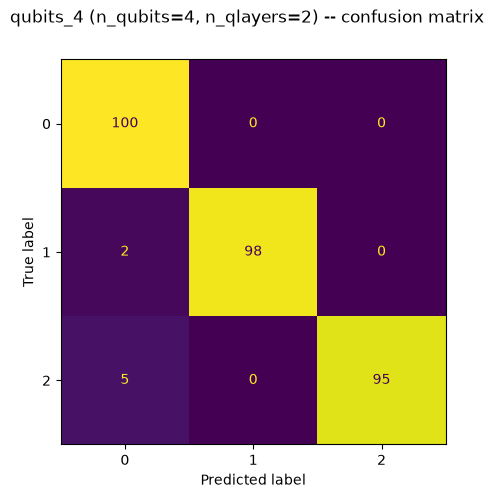

Saved D:\Dissertation\qcnn-dissertation\results\ablation\qubits_6\confusion_matrix.png


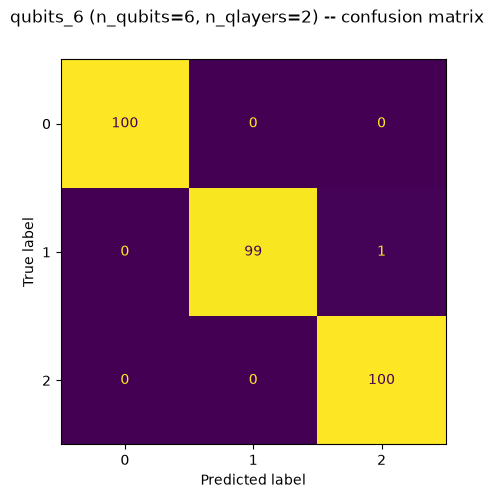

Saved D:\Dissertation\qcnn-dissertation\results\ablation\qubits_8\confusion_matrix.png


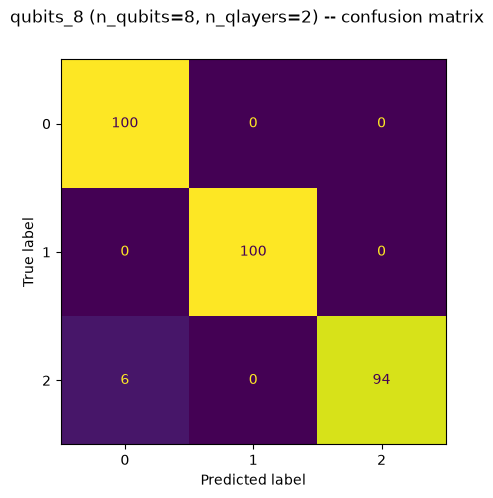

Saved D:\Dissertation\qcnn-dissertation\results\ablation\depth_1\confusion_matrix.png


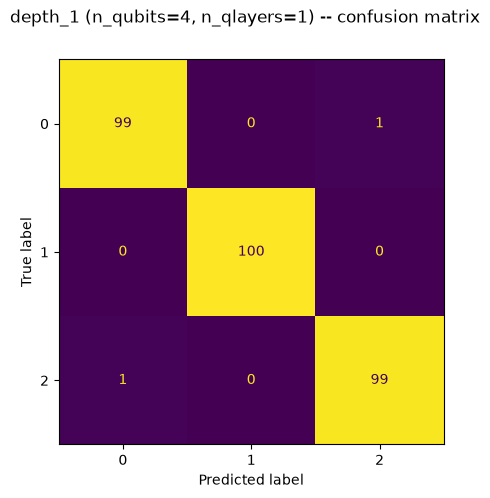

Saved D:\Dissertation\qcnn-dissertation\results\ablation\depth_2\confusion_matrix.png


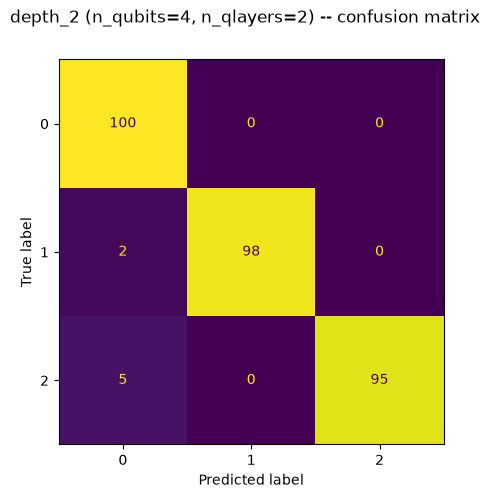

Saved D:\Dissertation\qcnn-dissertation\results\ablation\depth_3\confusion_matrix.png


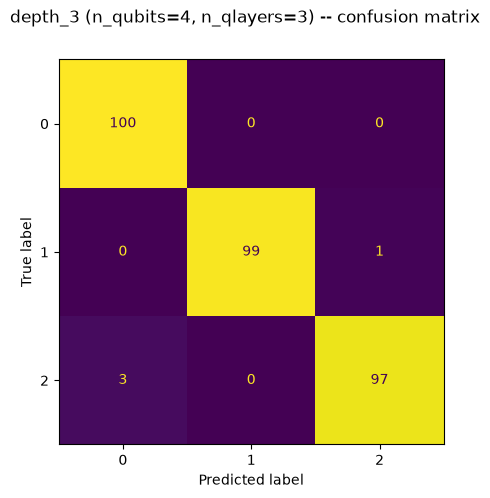

Saved D:\Dissertation\qcnn-dissertation\results\ablation\depth_4\confusion_matrix.png


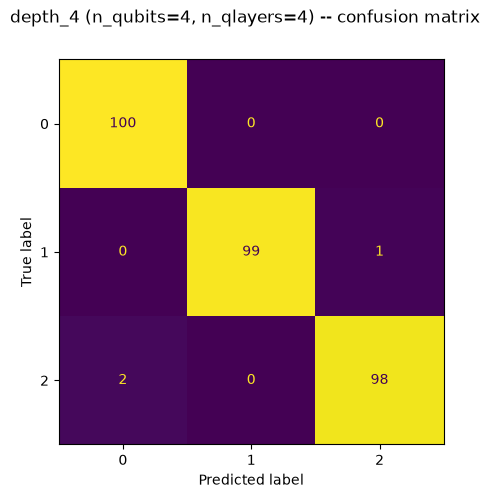

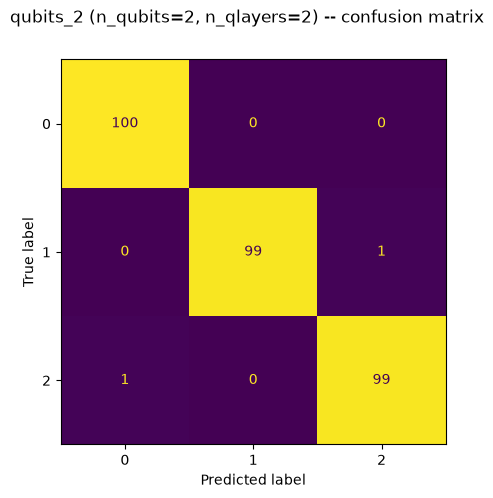

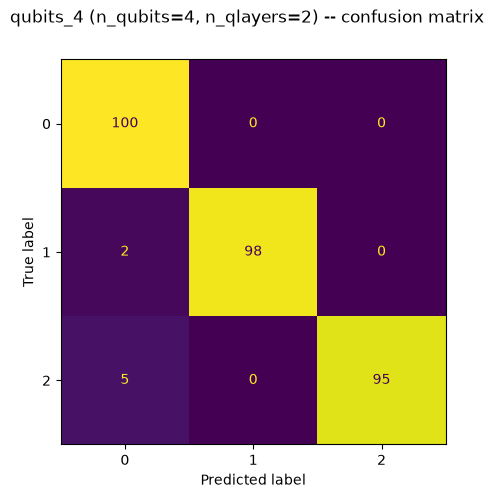

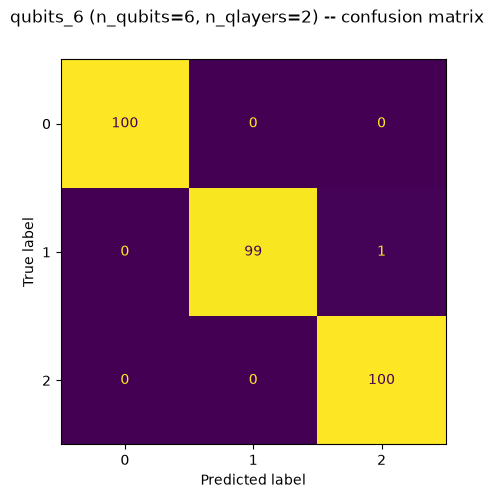

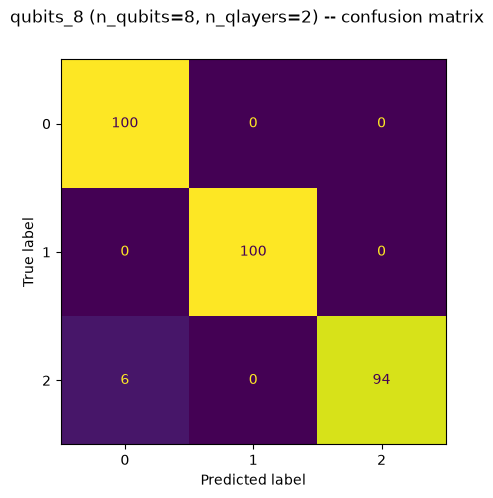

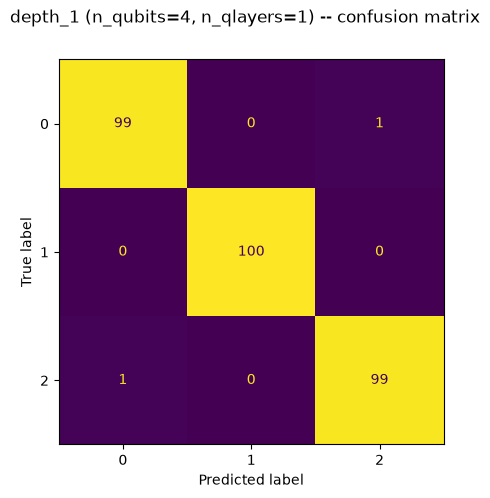

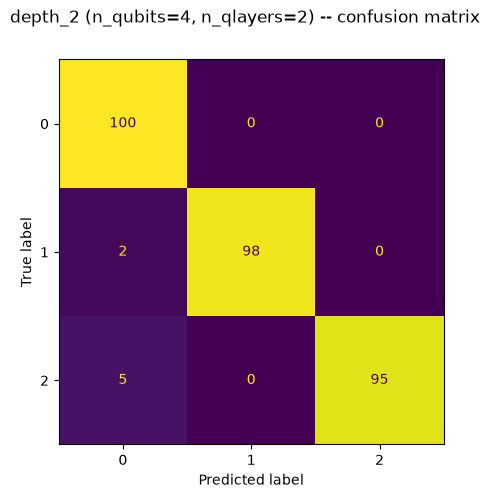

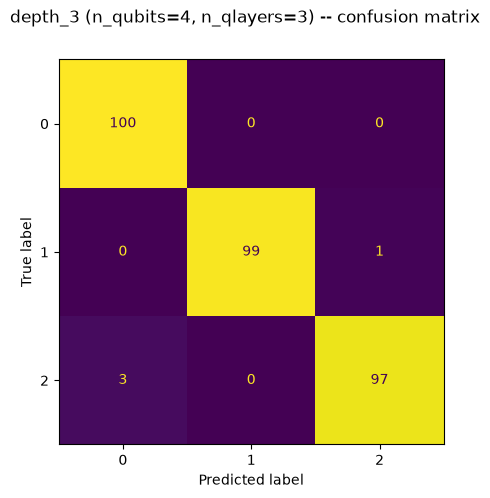

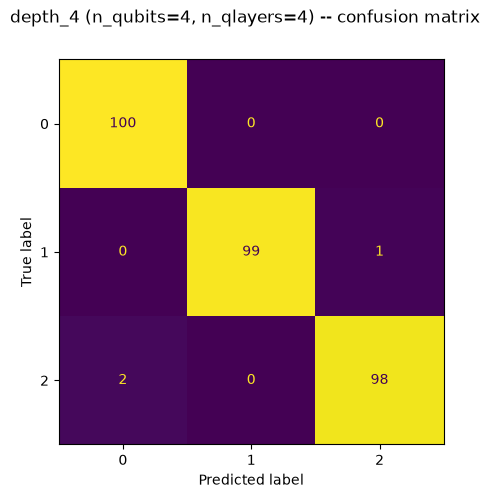

In [7]:
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for spec in SWEEP_A_RUNS + SWEEP_B_RUNS:
    if not spec['config'].exists():
        continue
    config = load_config(spec['config'])
    _, test_loader = get_dataloaders(config)

    model_cfg = config['model']
    model = HybridCNN(
        num_classes=model_cfg['num_classes'],
        n_qubits=model_cfg['n_qubits'],
        n_qlayers=model_cfg['n_qlayers'],
    )

    state_path = spec['results_dir'] / 'model.pt'
    if not state_path.exists():
        print(f"{spec['label']}: no saved weights found at {state_path}")
        continue

    model.load_state_dict(torch.load(state_path, map_location='cpu'))
    model.to(device)
    model.eval()

    with torch.no_grad():
        _, preds, labels = evaluate(model, test_loader, criterion, device)

    class_names = [str(c) for c in config['dataset']['classes']]
    fig = confusion_matrix_fig(labels, preds, class_names)
    fig.suptitle(
        f"{spec['label']} (n_qubits={model_cfg['n_qubits']}, "
        f"n_qlayers={model_cfg['n_qlayers']}) -- confusion matrix"
    )
    out_path = spec['results_dir'] / 'confusion_matrix.png'
    fig.savefig(out_path)
    print(f'Saved {out_path}')
    display(fig)

## Interpretation notes

**Sweep A (qubit count):** on this near-ceiling 3-class subset, accuracy does not rise monotonically with `n_qubits` (99.3% / 97.7% / 99.7% / 98.0% at 2/4/6/8 qubits) while parameter count grows steadily -- mostly driven by the classical-to-quantum bridge layer (`Linear(256, n_qubits)`), not the quantum circuit itself. That flat/noisy trend suggests the Phase 1 full-dataset accuracy gap is *not* well explained by quantum circuit capacity on this easy subset, and points toward encoding scheme, training budget, or optimizer as more likely causes -- a legitimate finding, not a failed experiment. A confirmatory full-dataset run at the best-performing qubit count is a reasonable follow-up if time allows.

**Sweep B (circuit depth):** accuracy is 99.3% / 97.7% / 98.7% / 99.0% at 1/2/3/4 entangling layers -- the *shallowest* circuit (1 layer) scores highest, and depth beyond the Phase 1 baseline (2 layers) does not produce a clean monotonic gain. `run_ablation.py`'s plateau heuristic (peak accuracy occurring below the maximum depth tested) fired, flagging this as consistent with the barren-plateau / vanishing-gradient effect known to affect deeper variational circuits. Given the small absolute spread (97.7-99.3%) on an already near-ceiling subset, this is also consistent with depth simply not mattering much for a 3-class problem this easy -- either reading is a legitimate, citable finding rather than an implementation bug, and both point toward testing on the harder full 10-class task before drawing firm conclusions about depth.